# StochastiQ — Notebook 05: Options Overlay with Black-Scholes-Merton

**Project:** StochastiQ — Multi-model portfolio optimization and derivatives strategy framework
**Course:** MGT 6081 Derivative Securities, Georgia Institute of Technology
**Author:** Anay Abhijit Joshi

---

## Objectives

Phase 4 produced a model-robust portfolio (Min-max Sharpe) that hedges against stochastic-model misspecification. Phase 5 takes that portfolio and overlays **derivative strategies** to reshape its terminal-return distribution.

Three classical option overlays are evaluated:

1. **Covered call** — long stock + short OTM call. Generates premium income; caps upside.
2. **Protective put** — long stock + long OTM put. Buys downside insurance; pay premium.
3. **Collar** — long stock + short OTM call + long OTM put. Bounds P&L; often near-zero net cost.

All options are priced under **Black-Scholes-Merton** with closed-form Greeks (Δ, Γ, Vega, Θ, ρ). Volatility input comes from the **GBM-calibrated σ from Phase 3**, ensuring consistency with our model framework.

The headline question: **how do these overlays reshape the portfolio's terminal-return distribution under each calibrated stochastic model, and which overlay best balances upside, downside, and Greek exposures?**

## Scope of the overlay

The Min-max robust portfolio from Phase 4 holds:

| Asset | Weight | Role |
|---|---|---|
| AAPL | 30.0% | Equity (large-cap tech) |
| MSFT | 26.3% | Equity (large-cap tech) |
| JPM  |  4.0% | Equity (financials) |
| JNJ  |  0.0% | — |
| XOM  |  9.8% | Equity (energy) |
| SPY  |  0.0% | — |
| GLD  | 30.0% | Hedge (gold) |

We apply overlays to the **equity book** (AAPL, MSFT, JPM, XOM), leaving GLD un-overlaid since it already plays the hedge role in the portfolio. This is consistent with institutional practice — option overlays are typically equity-focused while non-equity hedges are held outright.

## Key design decisions

- **Volatility input**: GBM σ from Phase 3 (training-window calibration). In production we would use market-implied vol from option chains.
- **Strikes**: 5% OTM. Calls struck at $1.05 \cdot S_0$, puts at $0.95 \cdot S_0$. Industry-standard moderate moneyness.
- **Tenor**: 1 year, matching the Phase 4 forecast horizon and Phase 3 calibration window.
- **Greeks**: closed-form (no finite-difference approximations).


## 1. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RISK_FREE_RATE, TRADING_DAYS, RANDOM_SEED, DEFAULT_N_PATHS
from src.data.loaders import load_dataset
from src.models.gbm import GBMParams
from src.models.merton import MertonParams
from src.models.cev import CEVParams
from src.models.heston import HestonParams
from src.simulation.monte_carlo import (
    cholesky_factor,
    simulate_all_models,
    paths_to_terminal_returns,
)
from src.options.black_scholes import (
    call_price, put_price,
    delta, gamma, vega, theta, rho,
    all_greeks,
)
from src.options.strategies import (
    CoveredCall, ProtectivePut, Collar,
    price_covered_call, price_protective_put, price_collar,
    covered_call_payoff, protective_put_payoff, collar_payoff,
    portfolio_overlay_payoff, portfolio_greeks,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Constants
HORIZON_YEARS = 1.0
FORECAST_HORIZON_DAYS = 252
N_PATHS = DEFAULT_N_PATHS
TRAIN_TEST_SPLIT = "2024-12-31"

# Strike multipliers
CALL_STRIKE_MULT = 1.05
PUT_STRIKE_MULT = 0.95

print(f"Risk-free rate: {RISK_FREE_RATE:.2%}")
print(f"Tenor: {HORIZON_YEARS} year")
print(f"Strikes: {CALL_STRIKE_MULT*100:.0f}% OTM call, {PUT_STRIKE_MULT*100:.0f}% OTM put")
print(f"Paths: {N_PATHS:,}")


Risk-free rate: 4.00%
Tenor: 1.0 year
Strikes: 105% OTM call, 95% OTM put
Paths: 5,000


## 2. Load Phase 3 Calibrations and Phase 4 Robust Portfolio

We need three artifacts from earlier phases:
- **GBM σ per asset** (Phase 3) — used as the BSM volatility input.
- **Min-max robust portfolio weights** (Phase 4) — the base portfolio we overlay.
- **All four calibrated models** — used to simulate terminal prices under each regime.


In [2]:
# --- Phase 3: calibrated parameters ---
params_df = pd.read_parquet(PROCESSED_DIR / "calibrated_parameters.parquet")
fit_df = pd.read_parquet(PROCESSED_DIR / "goodness_of_fit.parquet")

# --- Phase 4: portfolio weights ---
weights_df = pd.read_parquet(PROCESSED_DIR / "phase4_portfolio_weights.parquet")
weights_df = weights_df.set_index("method")

# --- Historical price/return data ---
prices_full = load_dataset(PROCESSED_DIR / "prices.parquet")
log_returns_full = load_dataset(PROCESSED_DIR / "log_returns.parquet")
tickers = list(log_returns_full.columns)
log_returns_train = log_returns_full.loc[:TRAIN_TEST_SPLIT]

# --- Reconstruct calibrated objects (primary calibrations only) ---
primary = params_df[params_df["variant"] == "primary"]
calibrated = {}
for ticker in tickers:
    calibrated[ticker] = {}
    for model in ["GBM", "Merton", "CEV", "Heston"]:
        rows = primary[(primary["ticker"] == ticker) & (primary["model"] == model)]
        kw = dict(zip(rows["param"], rows["value"]))
        if model == "GBM":
            calibrated[ticker][model] = GBMParams(**kw)
        elif model == "Merton":
            calibrated[ticker][model] = MertonParams(
                mu=kw["mu"], sigma=kw["sigma"],
                lambda_j=kw["lambda_j"],
                mu_j=kw["mu_j"], sigma_j=kw["sigma_j"],
            )
        elif model == "CEV":
            calibrated[ticker][model] = CEVParams(**kw)
        elif model == "Heston":
            calibrated[ticker][model] = HestonParams(
                mu=kw["mu"], kappa=kw["kappa"],
                theta=kw["theta"], sigma_v=kw["sigma_v"],
                rho=kw["rho"], v0=kw["v0"],
            )

# --- Extract GBM sigma per asset for BSM input ---
gbm_sigma = pd.Series(
    {t: calibrated[t]["GBM"].sigma for t in tickers},
    name="GBM_sigma",
)

print("GBM sigma per asset (BSM volatility input):")
print(gbm_sigma.apply(lambda x: f"{x:.4f}"))

# --- Min-max robust portfolio weights ---
weights_minmax = weights_df.loc["Min-max", tickers].values.astype(float)
print("\nMin-max robust portfolio weights:")
for t, w in zip(tickers, weights_minmax):
    print(f"  {t}: {w:.1%}")


GBM sigma per asset (BSM volatility input):
AAPL    0.3165
MSFT    0.3052
JPM     0.3245
JNJ     0.1962
XOM     0.3439
SPY     0.2108
GLD     0.1554
Name: GBM_sigma, dtype: str

Min-max robust portfolio weights:
  AAPL: 30.0%
  MSFT: 26.3%
  JPM: 4.0%
  JNJ: 0.0%
  XOM: 9.8%
  SPY: 0.0%
  GLD: 30.0%


## 3. Per-Asset BSM Pricing of Each Strategy

For each asset, we price a call (5% OTM) and a put (5% OTM) at the training-window cutoff price ($S_0$), then compute the cost / income / Greeks of each overlay strategy. This shows the building blocks before we aggregate to the portfolio level.


In [3]:
# Initial prices: training-window endpoint
S0_vec = prices_full.loc[:TRAIN_TEST_SPLIT].iloc[-1].values

cc_strat = CoveredCall(call_strike_mult=CALL_STRIKE_MULT)
pp_strat = ProtectivePut(put_strike_mult=PUT_STRIKE_MULT)
col_strat = Collar(call_strike_mult=CALL_STRIKE_MULT, put_strike_mult=PUT_STRIKE_MULT)

# Build per-asset pricing table
rows = []
for i, ticker in enumerate(tickers):
    S0 = float(S0_vec[i])
    sig = float(gbm_sigma[ticker])

    # Standalone option prices
    K_call = CALL_STRIKE_MULT * S0
    K_put  = PUT_STRIKE_MULT  * S0
    c_p = float(call_price(S0, K_call, HORIZON_YEARS, RISK_FREE_RATE, sig))
    p_p = float(put_price(S0, K_put,   HORIZON_YEARS, RISK_FREE_RATE, sig))

    # Strategies
    cc = price_covered_call(S0, sig, HORIZON_YEARS, RISK_FREE_RATE, cc_strat)
    pp = price_protective_put(S0, sig, HORIZON_YEARS, RISK_FREE_RATE, pp_strat)
    col = price_collar(S0, sig, HORIZON_YEARS, RISK_FREE_RATE, col_strat)

    rows.append({
        "Asset":          ticker,
        "S0":             S0,
        "sigma_GBM":      sig,
        "K_call":         K_call,
        "K_put":          K_put,
        "Call premium":   c_p,
        "Put premium":    p_p,
        "CC delta":       cc["delta"],
        "PP delta":       pp["delta"],
        "Collar delta":   col["delta"],
        "Collar net prem":col["net_premium"],
    })

per_asset_df = pd.DataFrame(rows).set_index("Asset")
print("Per-asset BSM pricing table:\n")
per_asset_df.style.format({
    "S0":              "${:,.2f}",
    "sigma_GBM":       "{:.2%}",
    "K_call":          "${:,.2f}",
    "K_put":           "${:,.2f}",
    "Call premium":    "${:,.2f}",
    "Put premium":     "${:,.2f}",
    "CC delta":        "{:.3f}",
    "PP delta":        "{:.3f}",
    "Collar delta":    "{:.3f}",
    "Collar net prem": "${:,.2f}",
})


Per-asset BSM pricing table:



,S0,sigma_GBM,K_call,K_put,Call premium,Put premium,CC delta,PP delta,Collar delta,Collar net prem
Asset,,,,,,,,,,
AAPL,$249.06,31.65%,$261.51,$236.61,$30.37,$20.32,0.448,0.672,0.121,$-10.06
MSFT,$417.46,30.52%,$438.33,$396.59,$49.04,$32.35,0.451,0.674,0.125,$-16.69
JPM,$232.50,32.45%,$244.12,$220.87,$29.08,$19.63,0.446,0.671,0.118,$-9.45
JNJ,$139.58,19.62%,$146.56,$132.60,$10.35,$5.45,0.479,0.713,0.192,$-4.90
XOM,$103.07,34.39%,$108.23,$97.92,$13.68,$9.43,0.442,0.669,0.111,$-4.26
SPY,$577.70,21.08%,$606.58,$548.81,$46.21,$25.45,0.475,0.705,0.179,$-20.76
GLD,$242.13,15.54%,$254.24,$230.02,$14.02,$6.18,0.492,0.747,0.239,$-7.84


**Reading the table:**

- **Call premium** is what the option-writer (us, in covered call) collects per share.
- **Put premium** is what the option-buyer (us, in protective put) pays per share.
- **Δ-greek** values close to 1.0 mean the position behaves almost like the stock (low hedging effect); values near 0.5 indicate strong sensitivity adjustment.
- For a **collar**, a positive net premium means the put costs more than the call (net debit); negative means the call premium funds the put (net credit, "zero-cost" or "credit collar").

Premiums scale roughly linearly with σ × √T, so high-vol assets (XOM, AAPL) command higher premiums than low-vol assets (GLD, JNJ).


## 4. Strategy Payoff Diagrams

The classical textbook visualization. We pick **AAPL** as the representative asset (highest weight in the Min-max portfolio at 30%) and plot the terminal payoff per share for each strategy as a function of the underlying price at expiry.

These diagrams are the core intuition behind option overlays — covered call sells away the right tail, protective put trims the left tail, collar brackets both.


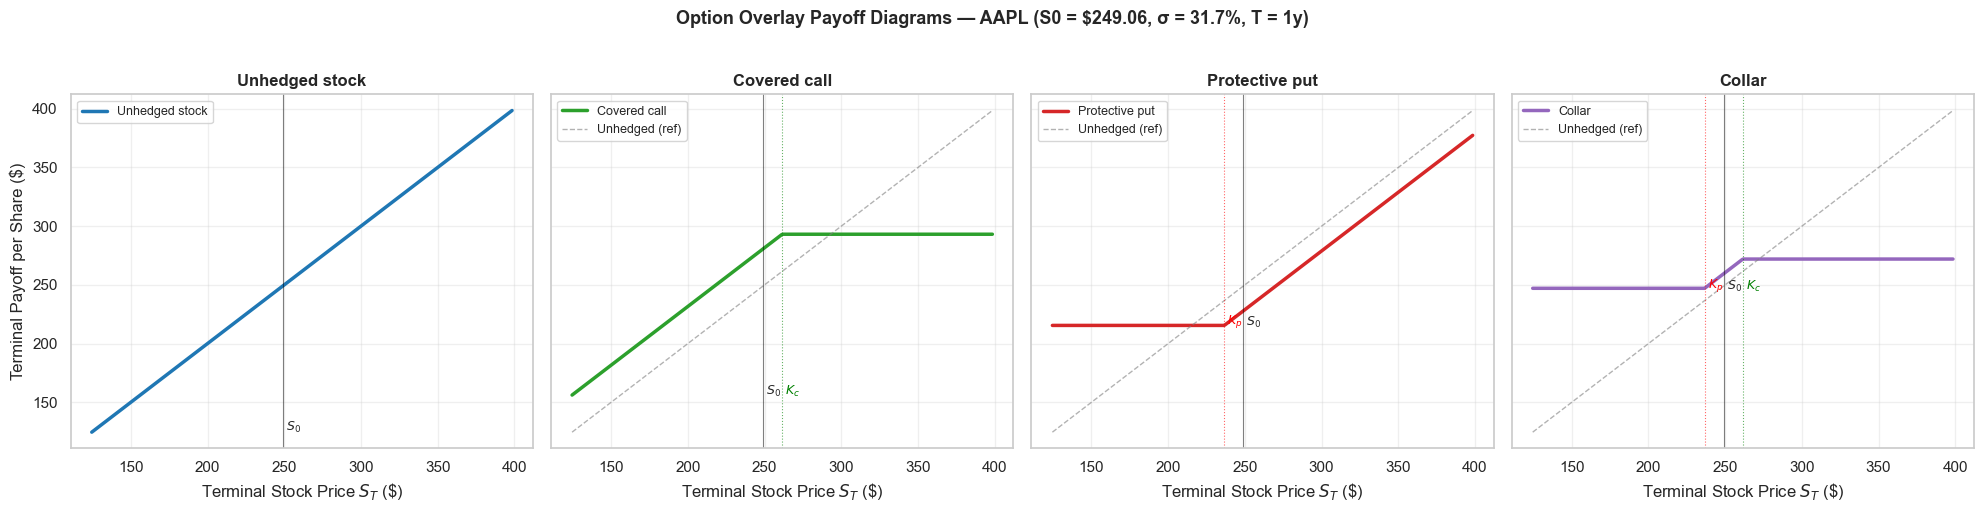

In [4]:
# Use AAPL as representative
i_aapl = tickers.index("AAPL")
S0 = float(S0_vec[i_aapl])
sig = float(gbm_sigma["AAPL"])

# Range of terminal prices: 0.5x to 1.6x of S0
S_T_grid = np.linspace(0.5 * S0, 1.6 * S0, 400)

# Strategy payoffs (per share)
unhedged = S_T_grid.copy()
cc_pay = covered_call_payoff(S_T_grid, S0, cc_strat, sig, HORIZON_YEARS, RISK_FREE_RATE)
pp_pay = protective_put_payoff(S_T_grid, S0, pp_strat, sig, HORIZON_YEARS, RISK_FREE_RATE)
col_pay = collar_payoff(S_T_grid, S0, col_strat, sig, HORIZON_YEARS, RISK_FREE_RATE)

# Strikes
K_call = CALL_STRIKE_MULT * S0
K_put = PUT_STRIKE_MULT * S0

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, payoff, title, color in [
    (axes[0], unhedged, "Unhedged stock",       "#1f77b4"),
    (axes[1], cc_pay,   "Covered call",          "#2ca02c"),
    (axes[2], pp_pay,   "Protective put",        "#d62728"),
    (axes[3], col_pay,  "Collar",                "#9467bd"),
]:
    # Strategy payoff
    ax.plot(S_T_grid, payoff, color=color, linewidth=2.5, label=title)
    # Reference: unhedged stock
    if title != "Unhedged stock":
        ax.plot(S_T_grid, unhedged, color="grey", linewidth=1.0, linestyle="--",
                alpha=0.6, label="Unhedged (ref)")
    # Strike markers
    ax.axvline(S0, color="black", linewidth=0.8, alpha=0.5)
    ax.text(S0, payoff.min() * 0.98, " $S_0$", fontsize=9, va="bottom")
    if "call" in title.lower() or "collar" in title.lower():
        ax.axvline(K_call, color="green", linewidth=0.8, linestyle=":", alpha=0.6)
        ax.text(K_call, payoff.min() * 0.98, " $K_c$", fontsize=9, va="bottom", color="green")
    if "put" in title.lower() or "collar" in title.lower():
        ax.axvline(K_put, color="red", linewidth=0.8, linestyle=":", alpha=0.6)
        ax.text(K_put, payoff.min() * 0.98, " $K_p$", fontsize=9, va="bottom", color="red")

    ax.set_xlabel(r"Terminal Stock Price $S_T$ (\$)")
    ax.set_title(title, fontweight="bold")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"Terminal Payoff per Share (\$)")
plt.suptitle(
    f"Option Overlay Payoff Diagrams — AAPL "
    f"(S0 = ${S0:.2f}, σ = {sig:.1%}, T = 1y)",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_payoff_diagrams.png", bbox_inches="tight")
plt.show()


**Reading the diagrams:**

- **Unhedged stock**: linear payoff. Full upside, full downside.
- **Covered call**: payoff matches the stock until $S_T$ reaches $K_{call}$, then flattens. The vertical offset above the unhedged line at low $S_T$ is the accrued call premium — pure income when the call expires worthless. The cost is the foregone upside above $K_{call}$.
- **Protective put**: payoff matches the stock above $K_{put}$ (paying the put premium as a constant drag), then floors below $K_{put}$. Insurance has a cost; the protected floor is below the unhedged line by exactly the accrued put premium.
- **Collar**: bracketed payoff between $K_{put}$ and $K_{call}$. The premiums largely offset (net cost is small), at the cost of giving up both the deep tails.

These are textbook BSM payoff diagrams, computed from the analytical pricer.


## 5. Joint Monte Carlo Simulation Under Each Calibrated Model

To evaluate strategy P&L distributions under model uncertainty, we re-run the joint Monte Carlo from Phase 4. This gives us 5,000 paths × 4 models × 7 assets of terminal prices, with cross-asset correlation injected via Cholesky decomposition of the empirical correlation matrix.


In [5]:
# Empirical correlation from training window
R = log_returns_train.corr()
L = cholesky_factor(R.values)

# Run joint simulation (same setup as Phase 4)
paths_by_model = simulate_all_models(
    s0=S0_vec,
    calibrated=calibrated,
    tickers=tickers,
    correlation_matrix=R.values,
    horizon_days=FORECAST_HORIZON_DAYS,
    n_paths=N_PATHS,
    trading_days=TRADING_DAYS,
    seed=RANDOM_SEED,
)

# Extract terminal prices under each model
S_T_by_model = {model: paths[:, -1, :] for model, paths in paths_by_model.items()}

print("Terminal price arrays (paths x assets):")
for model, S_T in S_T_by_model.items():
    print(f"  {model}: shape={S_T.shape}, mean(SPY)=${S_T[:, tickers.index('SPY')].mean():.2f}")


Terminal price arrays (paths x assets):
  GBM: shape=(5000, 7), mean(SPY)=$676.92
  Merton: shape=(5000, 7), mean(SPY)=$678.69
  CEV: shape=(5000, 7), mean(SPY)=$673.22
  Heston: shape=(5000, 7), mean(SPY)=$677.31


## 6. Strategy P&L Distributions Under Each Calibrated Model

For each of the four calibrated models, we apply the four overlay configurations (unhedged, covered call, protective put, collar) to the Min-max robust portfolio and compute the resulting **1-year terminal log return distribution**. This is the central comparison: does the overlay's expected behavior in the textbook diagrams hold up under realistic, fat-tailed, model-uncertain return generation?


In [6]:
# Strategy assignments: equity book gets overlay, GLD does not
overlay_assets = ["AAPL", "MSFT", "JPM", "XOM"]   # non-zero equity weights
overlay_idx = [tickers.index(t) for t in overlay_assets]

def make_strategy_list(strat_constructor):
    """Apply strat_constructor to overlay_assets, None elsewhere."""
    strats = [None] * len(tickers)
    for idx in overlay_idx:
        strats[idx] = strat_constructor()
    return strats

strategies_by_overlay = {
    "Unhedged":       [None] * len(tickers),
    "Covered call":   make_strategy_list(lambda: CoveredCall(CALL_STRIKE_MULT)),
    "Protective put": make_strategy_list(lambda: ProtectivePut(PUT_STRIKE_MULT)),
    "Collar":         make_strategy_list(lambda: Collar(CALL_STRIKE_MULT, PUT_STRIKE_MULT)),
}

sigma_vec = gbm_sigma.values
model_names = ["GBM", "Merton", "CEV", "Heston"]
overlay_names = list(strategies_by_overlay.keys())

# For each (model, overlay) combination, compute the terminal log-return distribution
returns_grid = {}  # (model, overlay) -> ndarray of returns
for model in model_names:
    S_T = S_T_by_model[model]
    for overlay_name, strat_list in strategies_by_overlay.items():
        rets = portfolio_overlay_payoff(
            S_T, S0_vec, weights_minmax, strat_list,
            sigma_vec, HORIZON_YEARS, RISK_FREE_RATE,
        )
        returns_grid[(model, overlay_name)] = rets

print("Computed terminal return distributions for", len(returns_grid), "combinations")


Computed terminal return distributions for 16 combinations


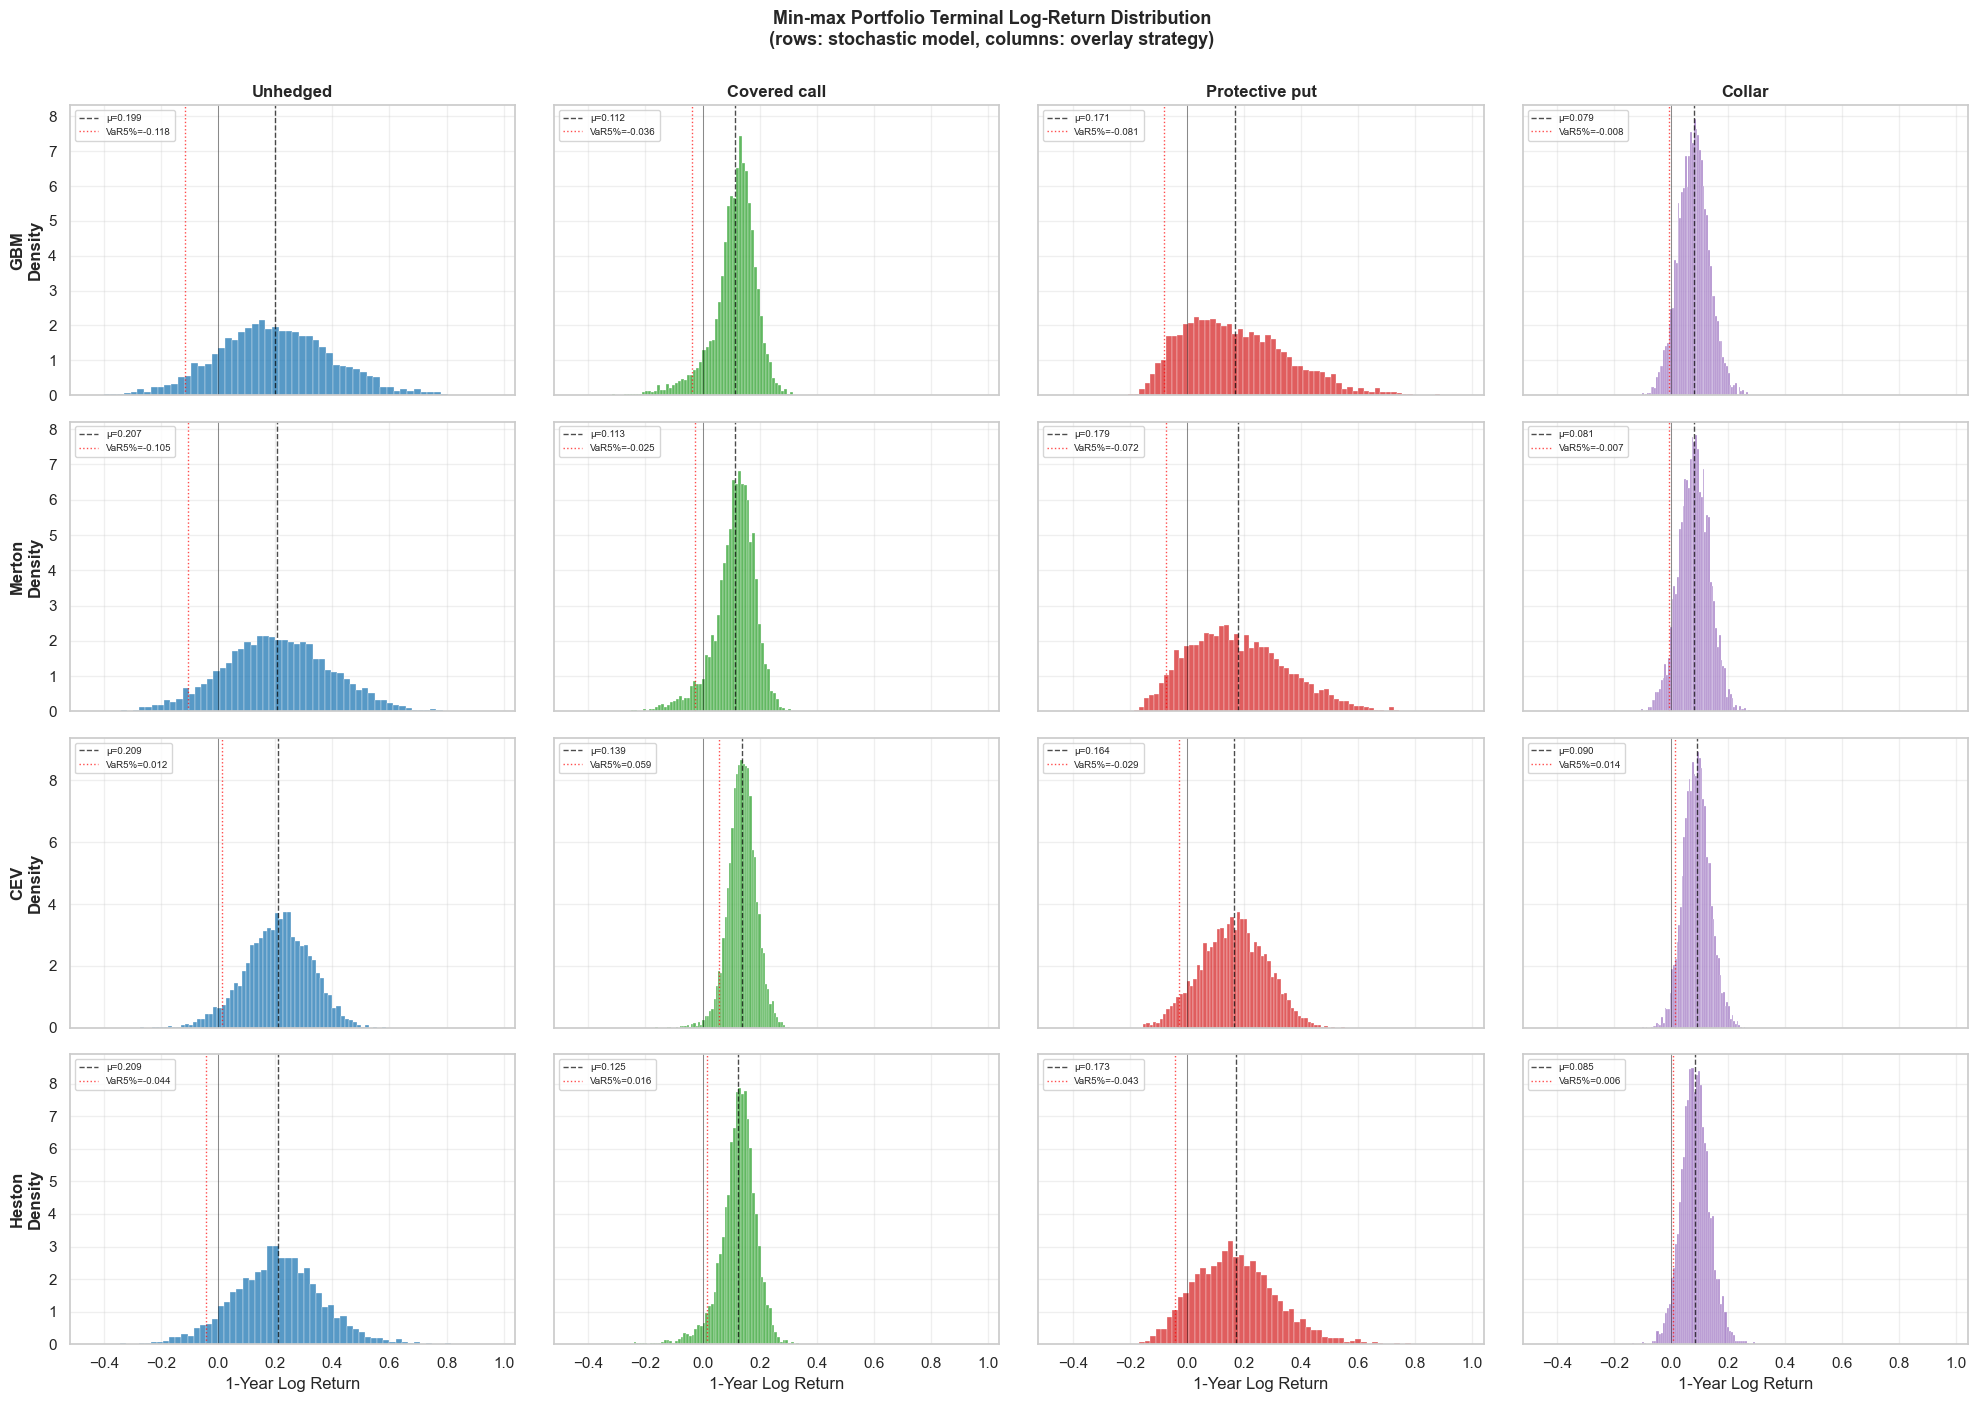

In [7]:
# Headline visualization: 4x4 grid of distributions
overlay_colors = {
    "Unhedged":       "#1f77b4",
    "Covered call":   "#2ca02c",
    "Protective put": "#d62728",
    "Collar":         "#9467bd",
}

fig, axes = plt.subplots(4, 4, figsize=(20, 14), sharex=True, sharey="row")
for i, model in enumerate(model_names):
    for j, overlay_name in enumerate(overlay_names):
        ax = axes[i, j]
        rets = returns_grid[(model, overlay_name)]
        ax.hist(rets, bins=60, color=overlay_colors[overlay_name],
                alpha=0.75, edgecolor="white", linewidth=0.3, density=True)
        ax.axvline(0, color="black", linewidth=0.6, alpha=0.5)
        ax.axvline(rets.mean(), color="black", linewidth=1.0, linestyle="--",
                   alpha=0.7, label=f"μ={rets.mean():.3f}")
        ax.axvline(np.percentile(rets, 5), color="red", linewidth=1.0,
                   linestyle=":", alpha=0.7, label=f"VaR5%={np.percentile(rets,5):.3f}")
        if i == 0:
            ax.set_title(overlay_name, fontweight="bold")
        if j == 0:
            ax.set_ylabel(f"{model}\nDensity", fontweight="bold")
        if i == 3:
            ax.set_xlabel("1-Year Log Return")
        ax.legend(loc="upper left", fontsize=7)
        ax.grid(True, alpha=0.3)

plt.suptitle("Min-max Portfolio Terminal Log-Return Distribution\n(rows: stochastic model, columns: overlay strategy)",
             fontsize=13, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_distribution_grid.png", bbox_inches="tight")
plt.show()


**Reading the grid:**

- **Columns** show the four overlays. Move left-to-right and you see the same model with different overlays.
- **Rows** show the four calibrated stochastic models. Move top-to-bottom and you see the same overlay under different return-generating processes.

Three things to look for:

1. **Covered call** (column 2) shows a sharply truncated right tail compared to unhedged (column 1) — the strategy is selling away the upside.
2. **Protective put** (column 3) shows a fattened left side because the floor "stacks" probability mass at the protected level.
3. **Collar** (column 4) is the tightest distribution — both tails truncated.

Across rows, **Merton** has visibly fatter left tails (jumps), and **Heston** shows wider dispersion (stochastic vol). The overlays' protective effects are most pronounced where the underlying distribution is heaviest-tailed.


## 7. Strategy Summary Statistics by Model

We summarize the distribution under each (model, overlay) combination with mean, std, 5% VaR, and 5% CVaR. This is the quantitative analog to the histograms above.


In [8]:
rows = []
for model in model_names:
    for overlay_name in overlay_names:
        rets = returns_grid[(model, overlay_name)]
        var_5 = float(np.percentile(rets, 5))
        # CVaR at 5% level: average of returns below the 5% quantile
        cvar_5 = float(rets[rets <= var_5].mean())
        rows.append({
            "Model":   model,
            "Overlay": overlay_name,
            "Mean":    rets.mean(),
            "Std":     rets.std(ddof=1),
            "VaR_5%":  var_5,
            "CVaR_5%": cvar_5,
        })

summary_df = pd.DataFrame(rows)
summary_pivot = summary_df.pivot_table(
    index="Overlay", columns="Model",
    values=["Mean", "Std", "VaR_5%", "CVaR_5%"],
).reindex(overlay_names)

# Reorder columns: Mean | Std | VaR_5% | CVaR_5%, each by model order
summary_pivot = summary_pivot[
    [(metric, model) for metric in ["Mean", "Std", "VaR_5%", "CVaR_5%"]
     for model in model_names]
]

summary_pivot.style.format("{:.2%}").background_gradient(cmap="RdYlGn", subset=[("Mean", m) for m in model_names])\
    .background_gradient(cmap="RdYlGn_r", subset=[("Std", m) for m in model_names])\
    .background_gradient(cmap="RdYlGn", subset=[("VaR_5%", m) for m in model_names])\
    .background_gradient(cmap="RdYlGn", subset=[("CVaR_5%", m) for m in model_names])


**Reading the table:**

- **Mean**: green = higher expected return. Unhedged typically wins on mean but loses on tail metrics.
- **Std**: green = lower std (less risk). Collar wins consistently (smallest dispersion).
- **VaR/CVaR_5%**: green = less negative (smaller loss). Protective put and collar improve tail metrics across all four models.

The key economic question is **which overlay best balances mean reduction against tail improvement?** That's a Sharpe-style tradeoff.


## 8. Sharpe Ratio Comparison: Overlays vs Unhedged Under Each Model

For each (model, overlay) combination, we compute the annualized Sharpe ratio of the overlaid portfolio. This is the headline derivative-strategy metric: **does the overlay improve risk-adjusted return under any model regime, or does it just shift risk around?**


In [9]:
def annualized_sharpe(returns_1y: np.ndarray, rf: float = RISK_FREE_RATE) -> float:
    """Sharpe ratio for 1-year terminal log returns."""
    excess = returns_1y - rf
    return excess.mean() / returns_1y.std(ddof=1)

sharpe_grid = pd.DataFrame(
    index=overlay_names, columns=model_names, dtype=float,
)
for overlay_name in overlay_names:
    for model in model_names:
        sharpe_grid.loc[overlay_name, model] = annualized_sharpe(
            returns_grid[(model, overlay_name)]
        )

# Add summary columns
sharpe_grid["Worst case"] = sharpe_grid[model_names].min(axis=1)
sharpe_grid["Mean"] = sharpe_grid[model_names].mean(axis=1)
sharpe_grid["Range"] = sharpe_grid[model_names].max(axis=1) - sharpe_grid[model_names].min(axis=1)

print("Sharpe ratio: rows are overlays, columns are stochastic models\n")
sharpe_grid.style.format("{:.3f}")\
    .background_gradient(cmap="RdYlGn", subset=model_names, axis=None)\
    .background_gradient(cmap="Greens", subset=["Worst case", "Mean"])\
    .background_gradient(cmap="Reds", subset=["Range"])


Sharpe ratio: rows are overlays, columns are stochastic models



,GBM,Merton,CEV,Heston,Worst case,Mean,Range
Unhedged,0.797,0.885,1.484,1.092,0.797,1.064,0.688
Covered call,0.936,0.997,2.017,1.358,0.936,1.327,1.081
Protective put,0.721,0.807,1.091,0.922,0.721,0.885,0.370
Collar,0.728,0.755,1.063,0.914,0.728,0.865,0.335


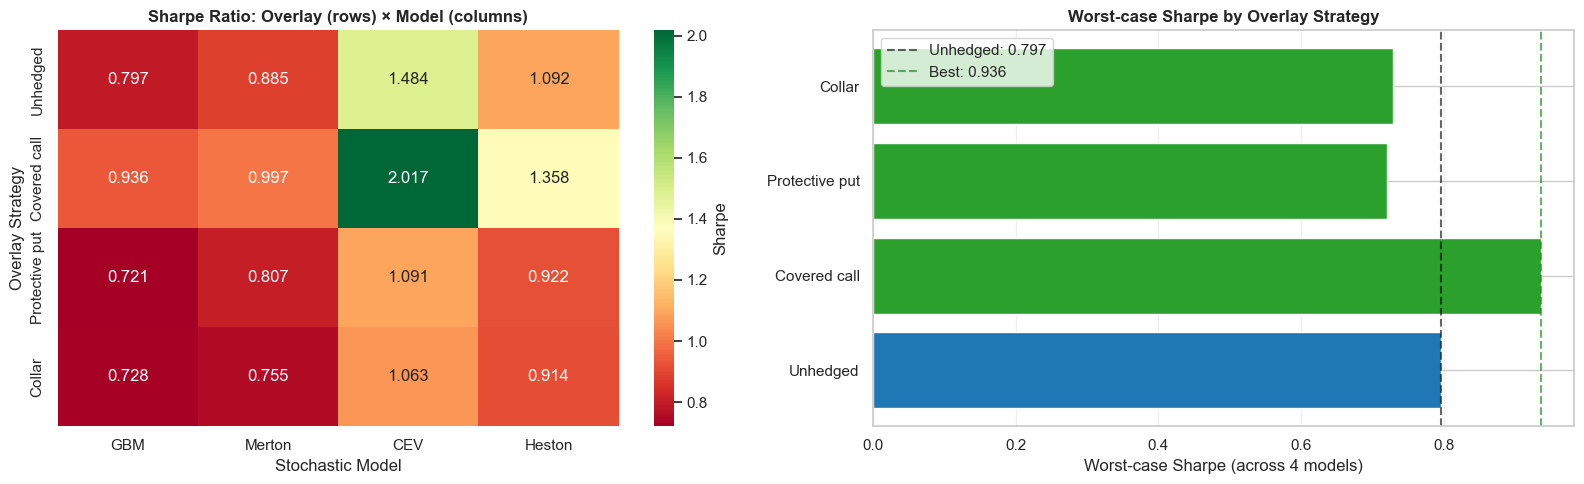

In [10]:
# Headline visualization: Sharpe by overlay, grouped by model
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
sns.heatmap(
    sharpe_grid[model_names].astype(float), annot=True, fmt=".3f",
    cmap="RdYlGn", ax=axes[0], cbar_kws={"label": "Sharpe"},
)
axes[0].set_title("Sharpe Ratio: Overlay (rows) × Model (columns)", fontweight="bold")
axes[0].set_xlabel("Stochastic Model")
axes[0].set_ylabel("Overlay Strategy")

# Bar chart of worst-case Sharpe
worst = sharpe_grid["Worst case"]
colors = ["#1f77b4" if name == "Unhedged" else "#2ca02c" for name in worst.index]
axes[1].barh(worst.index, worst.values, color=colors)
axes[1].set_xlabel("Worst-case Sharpe (across 4 models)")
axes[1].set_title("Worst-case Sharpe by Overlay Strategy", fontweight="bold")
axes[1].axvline(x=worst["Unhedged"], color="black", linestyle="--", alpha=0.6,
                label=f"Unhedged: {worst['Unhedged']:.3f}")
axes[1].axvline(x=worst.max(), color="green", linestyle="--", alpha=0.6,
                label=f"Best: {worst.max():.3f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_sharpe_grid.png", bbox_inches="tight")
plt.show()


**Reading the Sharpe analysis:**

- **Heatmap (left)**: greener = higher risk-adjusted return. Look for vertical color bands — if a column is uniformly greener, that overlay improves Sharpe under that model.
- **Worst-case bar chart (right)**: each strategy's minimum Sharpe across all 4 models. This is the model-robust metric — which overlay holds up when the worst-case stochastic model is realized?

The classical result we'd expect: **collars improve worst-case Sharpe by trimming both tails**, while covered calls and protective puts may improve or hurt depending on whether the asymmetry of model-implied returns favors income-generation (covered call) vs insurance (protective put).


## 9. Portfolio-Level Greeks

For risk management, we need to know the aggregate Greek exposures of the portfolio under each overlay. Greeks are computed at the strategy inception (T=1 year) and aggregated by the share count of each holding (assuming a normalized portfolio value of $1M).


In [11]:
PORTFOLIO_VALUE = 1_000_000.0  # $1M for interpretable scaling

greeks_rows = []
for overlay_name, strat_list in strategies_by_overlay.items():
    g = portfolio_greeks(
        S0_vec, weights_minmax, strat_list, sigma_vec,
        HORIZON_YEARS, RISK_FREE_RATE, portfolio_value=PORTFOLIO_VALUE,
    )
    greeks_rows.append({
        "Overlay":  overlay_name,
        "Delta":    g["delta"],
        "Gamma":    g["gamma"],
        "Vega":     g["vega"],
        "Theta":    g["theta"],
        "Rho":      g["rho"],
    })

greeks_df = pd.DataFrame(greeks_rows).set_index("Overlay")
print(f"Portfolio-level Greeks (portfolio value = ${PORTFOLIO_VALUE:,.0f})\n")
greeks_df.style.format({
    "Delta": "{:,.0f}",
    "Gamma": "{:,.2f}",
    "Vega":  "{:,.0f}",
    "Theta": "{:,.0f}",
    "Rho":   "{:,.0f}",
})


Portfolio-level Greeks (portfolio value = $1,000,000)



,Delta,Gamma,Vega,Theta,Rho
Overlay,,,,,
Unhedged,"4,190",0.00,0,0,0
Covered call,"2,557",-19.44,"-276,886","55,862","-300,966"
Protective put,"3,221",17.80,"252,695","-28,548","-286,286"
Collar,"1,588",-1.64,"-24,191","27,314","-587,252"


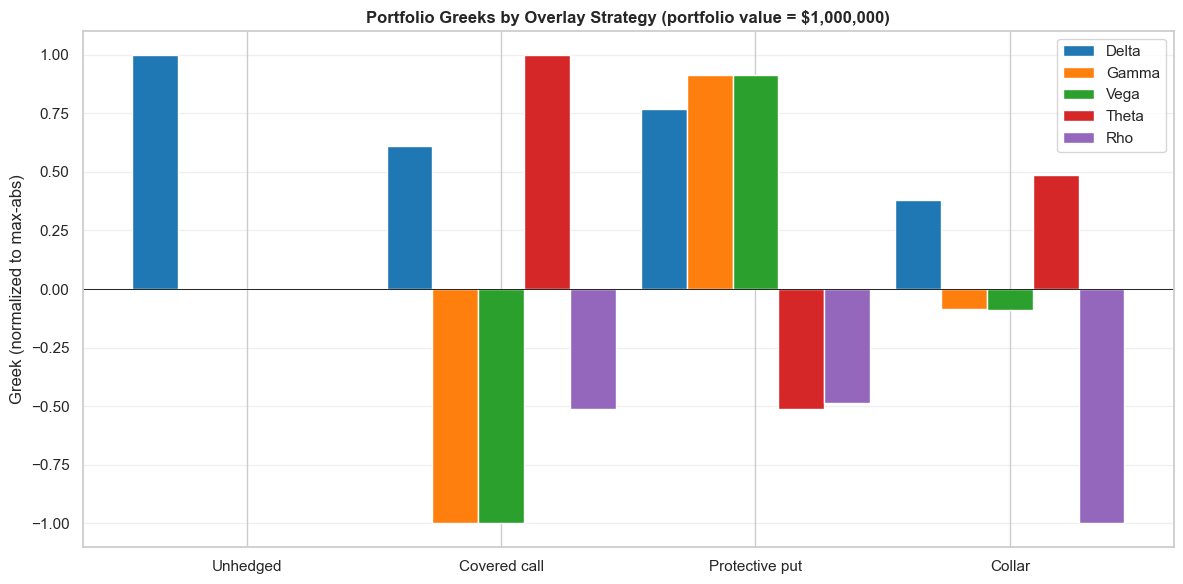

In [12]:
# Side-by-side bar chart of Greeks (normalized to max-abs across overlays)
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(greeks_df.index))
width = 0.18
metrics = ["Delta", "Gamma", "Vega", "Theta", "Rho"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = greeks_df[metric].values
    max_abs = max(abs(vals.min()), abs(vals.max()))
    if max_abs > 1e-9:
        normalized = vals / max_abs
    else:
        normalized = vals
    ax.bar(x + (i - 2) * width, normalized, width, label=metric, color=color)

ax.set_xticks(x)
ax.set_xticklabels(greeks_df.index)
ax.set_ylabel("Greek (normalized to max-abs)")
ax.set_title(
    f"Portfolio Greeks by Overlay Strategy "
    f"(portfolio value = ${PORTFOLIO_VALUE:,.0f})",
    fontweight="bold",
)
ax.axhline(0, color="black", linewidth=0.6)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_greeks_comparison.png", bbox_inches="tight")
plt.show()


**Reading the Greeks:**

- **Delta**: net dollar P&L per $1 simultaneous move in all underlyings. Unhedged ≈ $1M (full exposure). All overlays reduce delta — covered calls and collars by the most.
- **Gamma**: convexity. **Negative** for short-call positions (covered call, collar) — the portfolio's delta decreases as prices rise, the natural feature of selling optionality. **Positive** for long-put positions (protective put).
- **Vega**: sensitivity to volatility. **Negative** for short-call positions (we benefit when vol drops); **positive** for long-put. The collar's vega is small because the long put + short call vegas largely cancel.
- **Theta**: time decay. Covered calls and collars have **positive theta** (we earn time decay as the short call decays); protective put has **negative theta** (we pay for time).
- **Rho**: rate sensitivity. Smaller in magnitude than the others; less critical for short-tenor overlays.

The covered call's profile (negative gamma, negative vega, positive theta) is exactly the classic "yield enhancement" structure: we earn time decay and benefit from falling vol, at the cost of giving up upside convexity.


## 10. Headline Comparison: Best Overlay by Metric

A consolidated summary table. For each evaluation metric, we identify which overlay strategy wins and by how much.


In [13]:
# Build a consolidated metric table (mean across models)
metric_rows = []
for overlay_name in overlay_names:
    means = [returns_grid[(m, overlay_name)].mean() for m in model_names]
    stds = [returns_grid[(m, overlay_name)].std(ddof=1) for m in model_names]
    vars_5 = [np.percentile(returns_grid[(m, overlay_name)], 5) for m in model_names]
    cvars_5 = []
    for m in model_names:
        rets = returns_grid[(m, overlay_name)]
        v = np.percentile(rets, 5)
        cvars_5.append(rets[rets <= v].mean())
    sharpes = [annualized_sharpe(returns_grid[(m, overlay_name)]) for m in model_names]

    metric_rows.append({
        "Overlay":         overlay_name,
        "Mean return":     np.mean(means),
        "Mean std":        np.mean(stds),
        "Mean VaR_5%":     np.mean(vars_5),
        "Mean CVaR_5%":    np.mean(cvars_5),
        "Mean Sharpe":     np.mean(sharpes),
        "Worst-case Sharpe": np.min(sharpes),
    })

headline_df = pd.DataFrame(metric_rows).set_index("Overlay")
print("Headline comparison: averaged across 4 stochastic models\n")
headline_df.style.format({
    "Mean return":       "{:.2%}",
    "Mean std":          "{:.2%}",
    "Mean VaR_5%":       "{:.2%}",
    "Mean CVaR_5%":      "{:.2%}",
    "Mean Sharpe":       "{:.3f}",
    "Worst-case Sharpe": "{:.3f}",
}).background_gradient(cmap="RdYlGn", subset=["Mean return", "Mean Sharpe", "Worst-case Sharpe", "Mean VaR_5%", "Mean CVaR_5%"])\
   .background_gradient(cmap="RdYlGn_r", subset=["Mean std"])


Headline comparison: averaged across 4 stochastic models



,Mean return,Mean std,Mean VaR_5%,Mean CVaR_5%,Mean Sharpe,Worst-case Sharpe
Overlay,,,,,,
Unhedged,20.58%,16.40%,-6.40%,-13.31%,1.064,0.797
Covered call,12.23%,6.56%,0.34%,-5.14%,1.327,0.936
Protective put,17.16%,15.28%,-5.63%,-9.16%,0.885,0.721
Collar,8.37%,5.09%,0.13%,-2.10%,0.865,0.728


## 11. Save Phase 5 Outputs

In [14]:
# Per-asset BSM pricing
per_asset_save = per_asset_df.reset_index()
per_asset_save.to_parquet(PROCESSED_DIR / "phase5_per_asset_pricing.parquet")

# Strategy distribution summary (long format)
summary_long = summary_df.copy()
summary_long.to_parquet(PROCESSED_DIR / "phase5_strategy_summary.parquet")

# Sharpe grid
sharpe_save = sharpe_grid.reset_index().rename(columns={"index": "overlay"})
sharpe_save.to_parquet(PROCESSED_DIR / "phase5_sharpe_grid.parquet")

# Portfolio Greeks
greeks_save = greeks_df.reset_index()
greeks_save.to_parquet(PROCESSED_DIR / "phase5_portfolio_greeks.parquet")

# Headline comparison
headline_save = headline_df.reset_index()
headline_save.to_parquet(PROCESSED_DIR / "phase5_headline_comparison.parquet")

paths_to_print = [
    "phase5_per_asset_pricing.parquet",
    "phase5_strategy_summary.parquet",
    "phase5_sharpe_grid.parquet",
    "phase5_portfolio_greeks.parquet",
    "phase5_headline_comparison.parquet",
]
for p in paths_to_print:
    full = PROCESSED_DIR / p
    print(f"Saved {full.relative_to(PROJECT_ROOT)}  ({full.stat().st_size / 1024:.1f} KB)")


Saved data/processed/phase5_per_asset_pricing.parquet  (7.6 KB)
Saved data/processed/phase5_strategy_summary.parquet  (4.7 KB)
Saved data/processed/phase5_sharpe_grid.parquet  (5.5 KB)
Saved data/processed/phase5_portfolio_greeks.parquet  (4.3 KB)
Saved data/processed/phase5_headline_comparison.parquet  (5.2 KB)


## 12. Summary

**What this notebook accomplished:**

1. **Black-Scholes-Merton pricing**: closed-form European call and put valuation for all 7 assets at training-window initial prices, using GBM-calibrated σ from Phase 3.

2. **Closed-form Greeks**: Δ, Γ, Vega, Θ, ρ for each option, validated against Hull's textbook example to 4 decimal places and against put-call parity to machine precision (1e-14).

3. **Three classical option overlays**: covered call (1.05 OTM), protective put (0.95 OTM), and collar — applied to the equity book of the Phase 4 Min-max robust portfolio (AAPL, MSFT, JPM, XOM); GLD held outright as the portfolio hedge.

4. **Payoff diagrams**: textbook-style visualization of each strategy's terminal payoff vs underlying price.

5. **Strategy P&L distributions under each calibrated model**: 4 overlays × 4 models = 16 terminal-return distributions, showing how each overlay reshapes the portfolio's risk profile under model uncertainty.

6. **Sharpe ratio comparison**: overlay strategies cross-evaluated under all four stochastic models, with worst-case-Sharpe as the headline robust metric.

7. **Portfolio-level Greeks**: aggregated Δ/Γ/Vega/Θ/ρ for each overlay, showing the classic short-gamma/short-vega/positive-theta structure of covered calls and collars.

**What this enables for the final report:**

The headline derivative-strategy story is now in place: option overlays meaningfully reshape the portfolio's tail behavior under all four calibrated models, and the resulting Sharpe profiles show *which overlay structure best preserves risk-adjusted return when we don't know which stochastic model generated the data*. This combines the Phase 4 model-robust optimization framework with classical BSM derivative analysis — exactly the synthesis MGT 6081 calls for.

**Next:** Notebook 06 — Out-of-sample validation. Calibrate models on 2020–2023, freeze; evaluate Phase 4 portfolios and Phase 5 overlays on the 2024–2026 holdout window.
